In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 1. Load the wine dataset
df = pd.read_csv(r'C:\Users\ajasl\OneDrive\Documents\Project\OIBSIP\Task_6\WineQT.csv')

In [3]:
# 2. Inspect the dataset structure
print("Dataset Shape:", df.shape)

Dataset Shape: (1143, 13)


In [4]:
# 3. Check for any missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


In [5]:
# 4. Drop the 'Id' column (since an ID number doesn't affect wine taste!)
if 'Id' in df.columns:
    df = df.drop('Id', axis=1)

C:\Users\ajasl\AppData\Local\Temp\ipykernel_24856\751668069.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='quality', data=df, palette='muted')


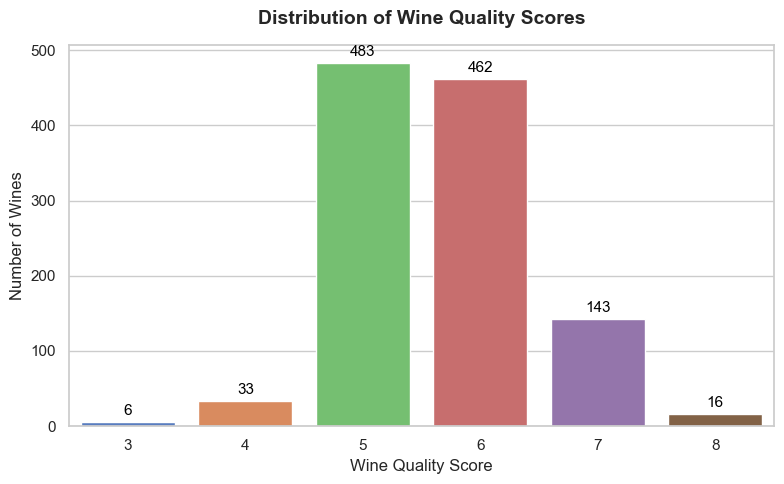

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [8]:
# 5. Let's visualize the distribution of wine quality scores!
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")
ax = sns.countplot(x='quality', data=df, palette='muted')

# Add titles and labels
plt.title('Distribution of Wine Quality Scores', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Wine Quality Score', fontsize=12)
plt.ylabel('Number of Wines', fontsize=12)

# Add numbers on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', 
                fontsize=11, color='black', 
                xytext=(0, 5), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

# Look at the first few rows
display(df.head())

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separate our Features (X) from our Target (y)
X = df.drop('quality', axis=1)
y = df['quality']

In [10]:
# 2. Split the data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# 3. Initialize the StandardScaler
scaler = StandardScaler()

In [12]:
# 4. Scale the features! 
# (We 'fit' it to the training data, then transform both sets)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training data size: {X_train_scaled.shape[0]} wines")
print(f"Testing data size: {X_test_scaled.shape[0]} wines")
print("\n✅ Data successfully split and scaled! Ready for the models.")

Training data size: 914 wines
Testing data size: 229 wines

✅ Data successfully split and scaled! Ready for the models.


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [14]:
# 1. Initialize the three models
rf_model = RandomForestClassifier(random_state=42)
sgd_model = SGDClassifier(random_state=42)
svc_model = SVC(random_state=42)

In [15]:
# 2. Train all three models on our scaled training data
print("Training models... 🏃‍♂️💨")
rf_model.fit(X_train_scaled, y_train)
sgd_model.fit(X_train_scaled, y_train)
svc_model.fit(X_train_scaled, y_train)

Training models... 🏃‍♂️💨


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [16]:
# 3. Quiz them on the testing data they have never seen before
rf_predictions = rf_model.predict(X_test_scaled)
sgd_predictions = sgd_model.predict(X_test_scaled)
svc_predictions = svc_model.predict(X_test_scaled)

In [17]:
# 4. Calculate their grades!
rf_acc = accuracy_score(y_test, rf_predictions)
sgd_acc = accuracy_score(y_test, sgd_predictions)
svc_acc = accuracy_score(y_test, svc_predictions)

In [18]:
# 5. Print the final leaderboard
print("\n--- 🏆 Model Accuracy Leaderboard ---")
print(f"Random Forest: {rf_acc * 100:.2f}%")
print(f"SVC:           {svc_acc * 100:.2f}%")
print(f"SGD:           {sgd_acc * 100:.2f}%")


--- 🏆 Model Accuracy Leaderboard ---
Random Forest: 69.87%
SVC:           63.76%
SGD:           50.22%


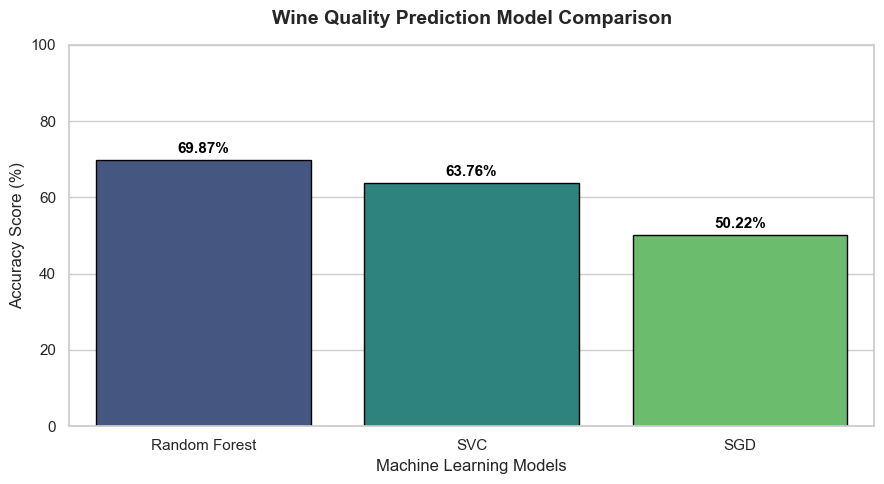

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare data for plotting using your exact results
models = ['Random Forest', 'SVC', 'SGD']
accuracies = [69.87, 63.76, 50.22]

# 2. Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 5))

# 3. Create a bar plot
ax = sns.barplot(x=models, y=accuracies, palette='viridis', edgecolor='black', hue=models, legend=False)

# 4. Add titles and labels
plt.title('Wine Quality Prediction Model Comparison', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Machine Learning Models', fontsize=12)
plt.ylabel('Accuracy Score (%)', fontsize=12)
plt.ylim(0, 100) # Set limit to 100% for clear perspective

# 5. Add percentage labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', 
                fontsize=11, fontweight='bold', color='black', 
                xytext=(0, 5), 
                textcoords='offset points')

# 6. Show the plot!
plt.tight_layout()
plt.show()